<a href="https://colab.research.google.com/github/GabrielaRguezCampos/MiamiHeatRecommendationCupon/blob/main/Final_total_img_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Set Data

In [ ]:
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import gdown
import time


In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

# Step 1: Load the full dataset
df = pd.read_csv('products_export_1.csv')


Saving products_export_1.csv to products_export_1 (4).csv


<ipython-input-5-18d5101008f6>:7: DtypeWarning: Columns (10,26,31,32,33,34,35,37,38,47,48,51,53,54,58,64,65,66) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('products_export_1.csv')


### Drop Columns

In [ ]:
columns_to_keep = ['Handle', 'Variant SKU', 'Image Src', 'Image Position', 'Title']
df = df[columns_to_keep].copy()
df.head()

,Handle,Variant SKU,Image Src,Image Position,Title
0,miami-heat-jibbitz,'141168,https://cdn.shopify.com/s/files/1/1368/0393/fi...,1.0,Crocs Miami HEAT Logo Jibbitz
1,miami-heat-jibbitz,NaN,https://cdn.shopify.com/s/files/1/1368/0393/fi...,2.0,NaN
2,miami-heat-jibbitz,NaN,https://cdn.shopify.com/s/files/1/1368/0393/fi...,3.0,NaN
3,24-25-donruss-retail-box,'141246,https://cdn.shopify.com/s/files/1/1368/0393/fi...,1.0,2024-25 Panini Donruss Retail Box
4,24-25-donruss-retail-box,NaN,https://cdn.shopify.com/s/files/1/1368/0393/fi...,2.0,NaN


### Check for unique image URLs

In [ ]:
# Count unique image URLs

num_unique_images = df['Image Src'].nunique()
print(f"Number of unique image URLs before check for duplicates: {num_unique_images}")


Number of unique image URLs before check for duplicates: 19886


### Select images with Image Position = 1.0

In [ ]:
# Ensure 'Position' is numeric
print(df['Image Position'].dtype)

float64


In [ ]:
# Filter for Position == 1.0 and show first 10
df_position1 = df[df['Image Position'] == 1.0]


# Count how many images after filtering by position
count = df_position1.shape[0]
print(f"Number of rows with Image Position == 1.0: {count}")

Number of rows with Image Position == 1.0: 8542


In [ ]:
# Get the first 50 image URLs
urls = df_position1['Image Src'].dropna().unique()[:50]



### Resize and store 50 images

In [ ]:
from PIL import Image
import requests
from io import BytesIO

resized_images = []
resized_urls = df_position1['Image Src'].dropna().unique()[:50]

for i, url in enumerate(resized_urls):
    try:
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert("RGBA")
        img_resized = img.resize((224, 224))
        resized_images.append(img_resized)
    except Exception as e:
        print(f"Image {i+1} failed to resize: {e}")


In [ ]:
print(f"Total resized images: {len(resized_images)}")


Total resized images: 50


### Display resized images

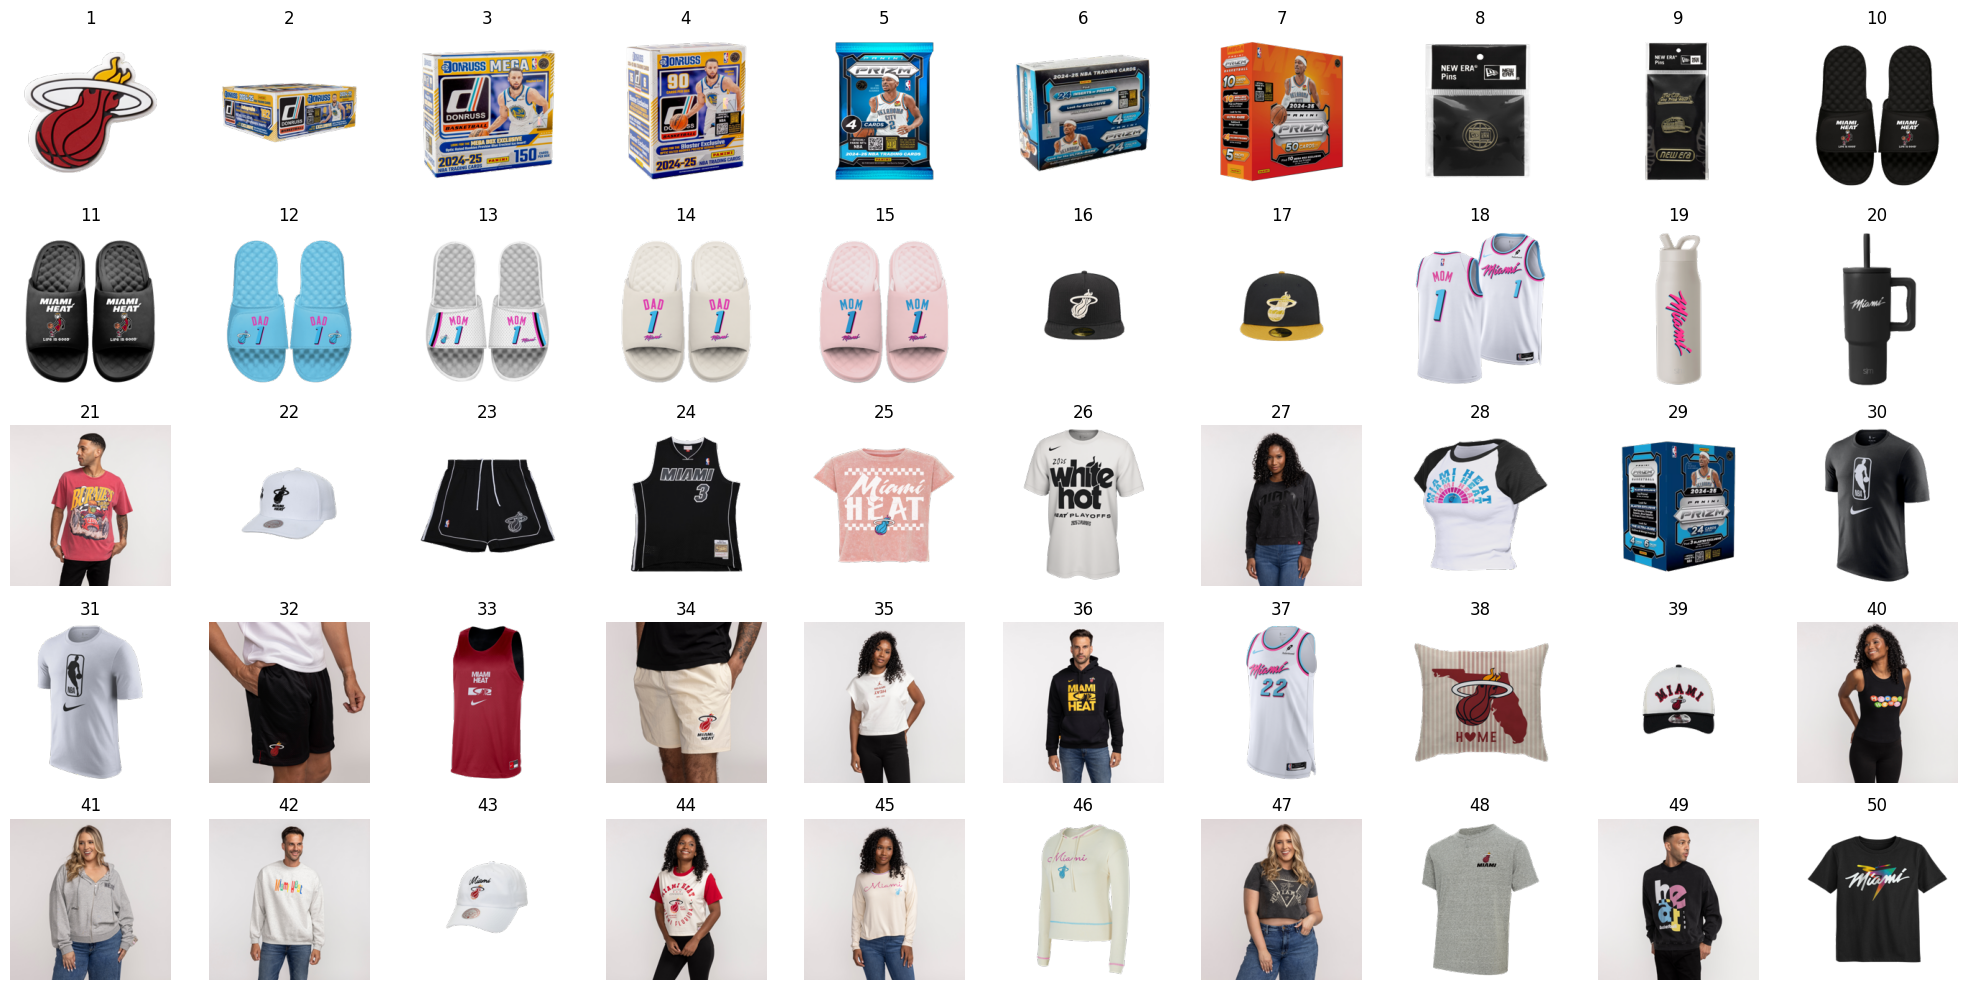

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
for i, img in enumerate(resized_images):
    plt.subplot(5, 10, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{i+1}")
plt.tight_layout()
plt.show()


### Remove background from re-sized images (100)

In [ ]:
!pip install rembg
!pip install onnxruntime

In [ ]:
from rembg import remove

bg_removed_images = []

for i, img in enumerate(resized_images):
    try:
        # Convert to bytes
        buffered = BytesIO()
        img.save(buffered, format="PNG")
        img_bytes = buffered.getvalue()

        # Remove background
        output = remove(img_bytes)
        cleaned = Image.open(BytesIO(output)).convert("RGBA")
        bg_removed_images.append(cleaned)
    except Exception as e:
        print(f"Image {i+1} failed to remove bg: {e}")


### Display background-removed images (100)

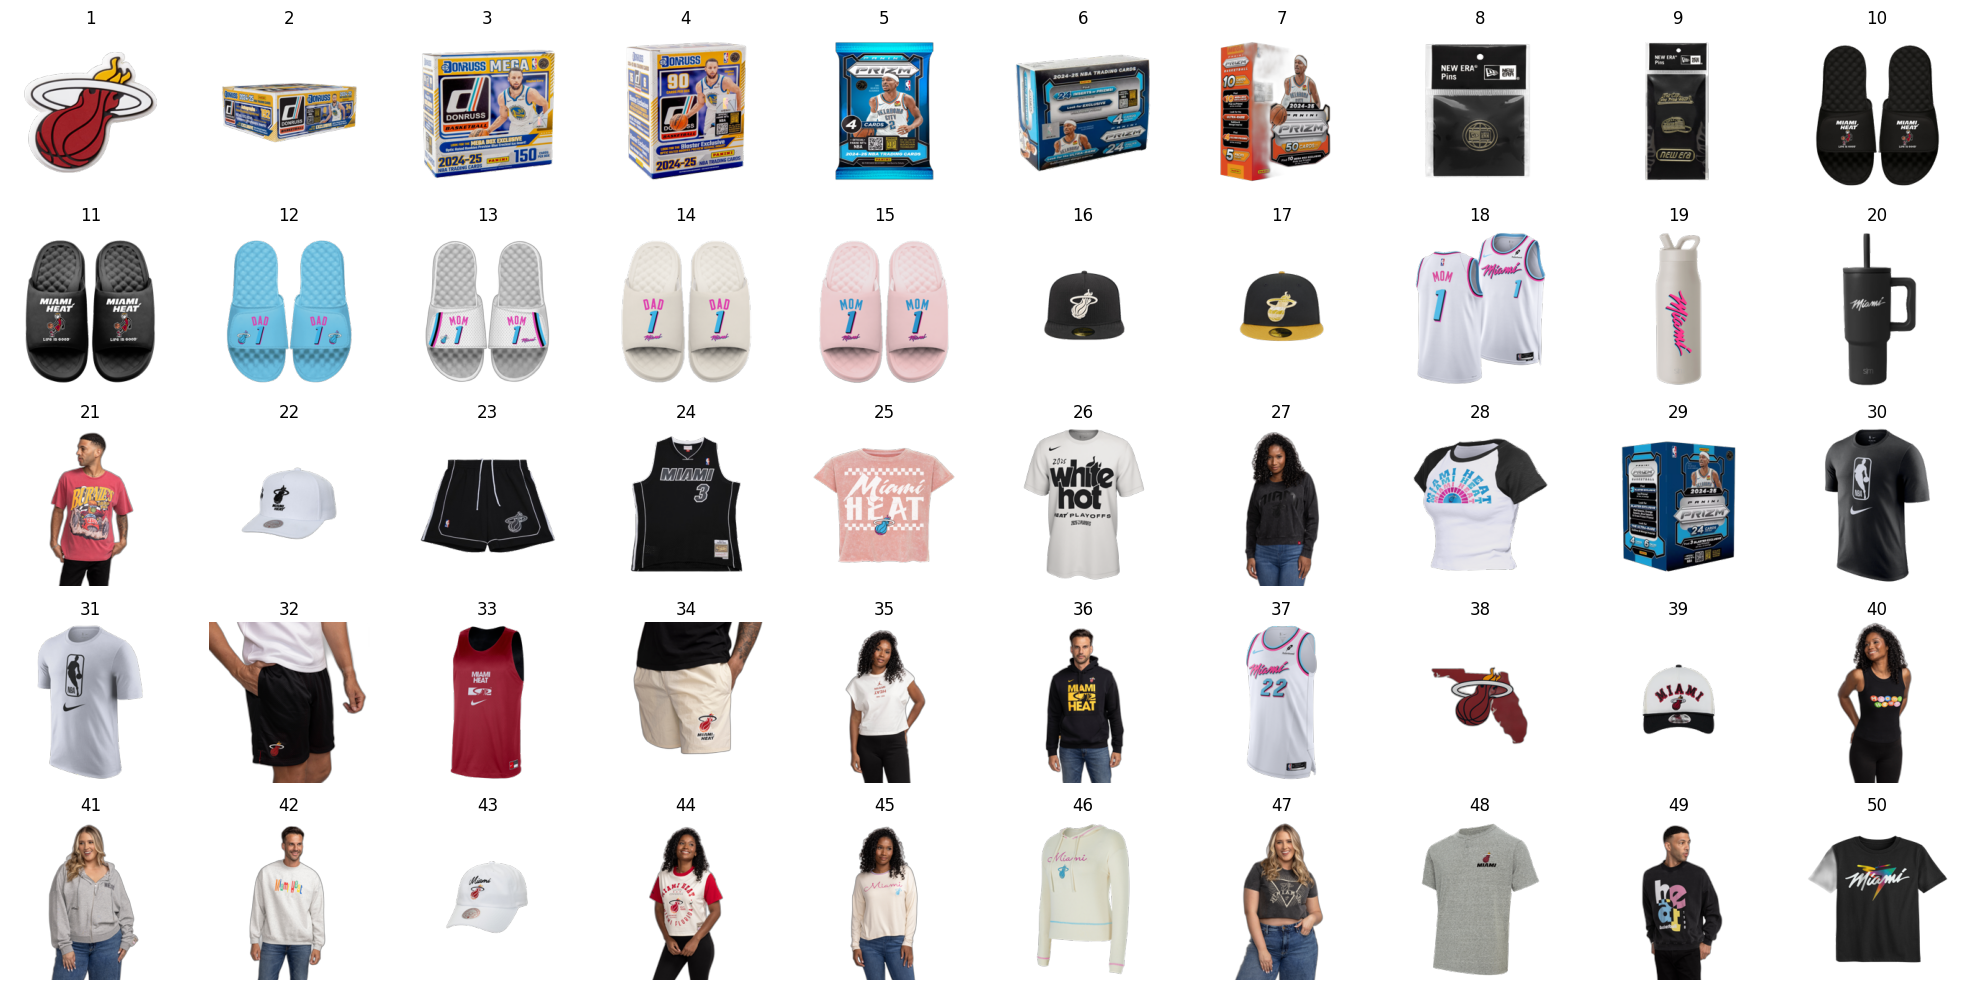

In [ ]:
plt.figure(figsize=(20, 10))
for i, img in enumerate(bg_removed_images):
    plt.subplot(5, 10, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{i+1}")
plt.tight_layout()
plt.show()


### Save background-removed images locally

In [ ]:
import os

# Create a folder to store them
save_path = "bg_removed_resized"
os.makedirs(save_path, exist_ok=True)

# Save images
for i, img in enumerate(bg_removed_images):
    img_path = os.path.join(save_path, f"image_{i+1}.png")
    img.save(img_path)


### Convert images to NumPy array for MobileNetV2

In [ ]:
processed_array = []

for img in bg_removed_images:
    img_rgb = img.convert("RGB")           # Convert each image
    img_np = np.array(img_rgb) / 255.0     # Normalize
    processed_array.append(img_np)

input_tensor = np.array(processed_array)
print("Input shape for MobileNetV2:", input_tensor.shape)



Input shape for MobileNetV2: (50, 224, 224, 3)


### CNN Feature Extraction Using MobileNetV2 pretrained in Imagenet (50 images)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np

# Load the pretrained model (no classification layer, outputs 1280D vector)
model = MobileNetV2(include_top=False, input_shape=(224, 224, 3), pooling='avg', weights='imagenet')



In [ ]:
# Preprocess input using MobileNetV2's method
preprocessed_input = preprocess_input(input_tensor.copy())  # <- important: apply this instead of /255

# Extract features
features = model.predict(preprocessed_input, verbose=1)  # (50, 1280)

# Optional: Store as list if needed
embeddings = features.tolist()

print("Features shape:", features.shape)  # ➜ (50, 1280)

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step
Features shape: (50, 1280)


### Apply SVD to Reduce Dimensions

In [ ]:
from sklearn.decomposition import TruncatedSVD

# Set target dimension (e.g., reduce to 50 components)
svd = TruncatedSVD(n_components=50, random_state=42)

# Apply SVD on the CNN feature vectors
svd_features = svd.fit_transform(features)

# Show the shape after reduction
print("SVD-reduced feature shape:", svd_features.shape)


SVD-reduced feature shape: (50, 50)


### Apply t-SNE for 2D Visualization

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

# Reduce to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
tsne_result = tsne.fit_transform(svd_features)

# Add x and y to a new DataFrame (or update existing one)
df_viz = df_position1[['Image Src','Handle' ]].dropna().drop_duplicates().head(50).copy()
df_viz['x'] = tsne_result[:, 0]
df_viz['y'] = tsne_result[:, 1]


In [ ]:
tsne_result.shape

(50, 2)

### KMeans Clustering

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
df_viz['cluster'] = kmeans.fit_predict(df_viz[['x', 'y']])


### Assign and Save Clusters to Each Product

In [ ]:
# If df_viz has 'Image Src' and 'cluster', merge back to df_position1 or df
df_clustered = df_position1.merge(df_viz[['Image Src', 'cluster']], on='Image Src', how='left')


In [ ]:
df_clustered.head()

,Handle,Variant SKU,Image Src,Image Position,Title,cluster
0,miami-heat-jibbitz,'141168,https://cdn.shopify.com/s/files/1/1368/0393/fi...,1.0,Crocs Miami HEAT Logo Jibbitz,4.0
1,24-25-donruss-retail-box,'141246,https://cdn.shopify.com/s/files/1/1368/0393/fi...,1.0,2024-25 Panini Donruss Retail Box,2.0
2,24-25-donruss-mega-box,'141244,https://cdn.shopify.com/s/files/1/1368/0393/fi...,1.0,2024-25 Panini Donruss Mega Box,2.0
3,24-25-donruss-blaster-box,'141243,https://cdn.shopify.com/s/files/1/1368/0393/fi...,1.0,2024-25 Panini Donruss Blaster Box,2.0
4,24-25-prizm-nba-retail-pack,'141212,https://cdn.shopify.com/s/files/1/1368/0393/fi...,1.0,2024-25 Panini Prizm NBA Retail Pack,2.0


### Visualize Clusters with Thumbnails

Skipping index 57 due to mismatch
Skipping index 71 due to mismatch
Skipping index 83 due to mismatch
Skipping index 92 due to mismatch
Skipping index 100 due to mismatch
Skipping index 108 due to mismatch
Skipping index 114 due to mismatch
Skipping index 115 due to mismatch
Skipping index 116 due to mismatch
Skipping index 122 due to mismatch
Skipping index 126 due to mismatch
Skipping index 131 due to mismatch
Skipping index 138 due to mismatch
Skipping index 143 due to mismatch
Skipping index 148 due to mismatch
Skipping index 153 due to mismatch
Skipping index 157 due to mismatch
Skipping index 159 due to mismatch
Skipping index 165 due to mismatch
Skipping index 171 due to mismatch
Skipping index 179 due to mismatch
Skipping index 185 due to mismatch
Skipping index 191 due to mismatch
Skipping index 196 due to mismatch
Skipping index 201 due to mismatch
Skipping index 206 due to mismatch
Skipping index 207 due to mismatch
Skipping index 214 due to mismatch
Skipping index 221 due t

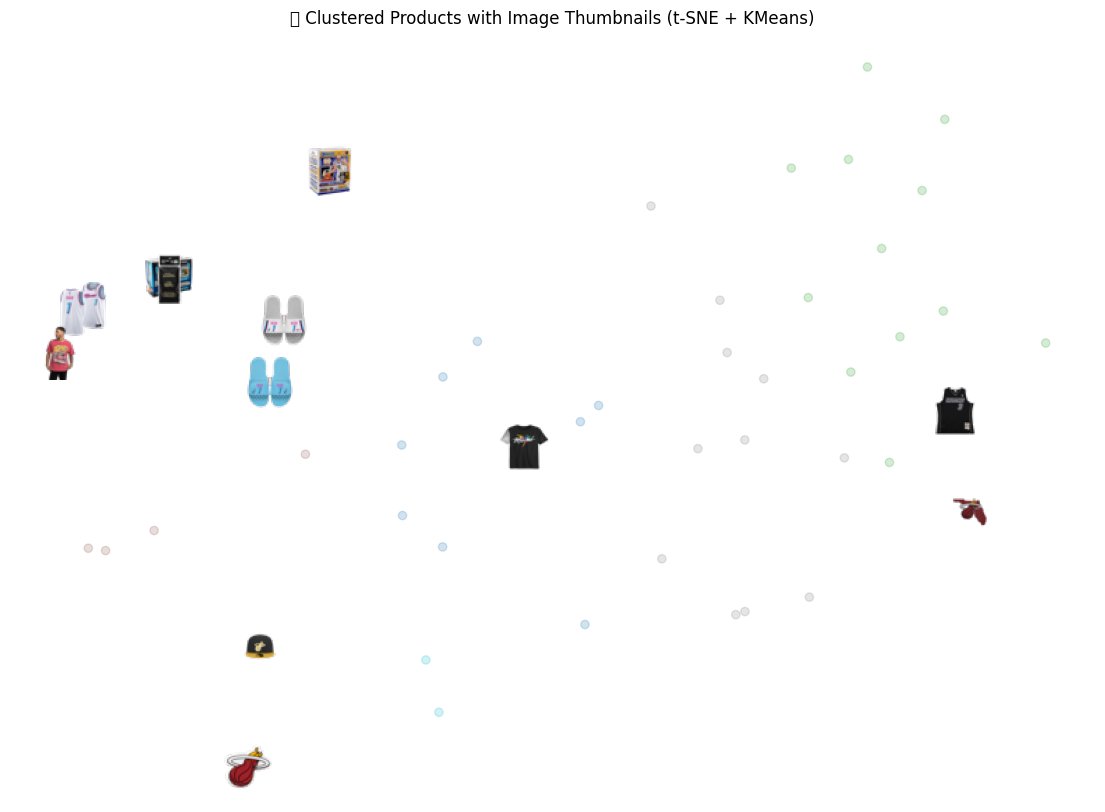

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.pyplot as plt

# Set up plot
fig, ax = plt.subplots(figsize=(14, 10))

# Assign a color to each cluster
colors = plt.cm.tab10(df_viz['cluster'] / df_viz['cluster'].max())

# Plot transparent points for layout
ax.scatter(df_viz['x'], df_viz['y'], c=colors, alpha=0.2)

# Overlay thumbnails
for i, row in df_viz.iterrows():
    try:
        img = bg_removed_images[i]               # Match image by index
        img.thumbnail((40, 40))                  # Resize thumbnail
        imagebox = OffsetImage(img)
        ab = AnnotationBbox(imagebox, (row['x'], row['y']), frameon=False)
        ax.add_artist(ab)
    except IndexError:
        print(f"Skipping index {i} due to mismatch")

# Finalize plot
plt.title("🧩 Clustered Products with Image Thumbnails (t-SNE + KMeans)")
plt.axis("off")
plt.show()



### Export Final Product-to-Cluster Table

In [ ]:
df_clustered.to_csv("products_with_clusters.csv", index=False)
